In [1]:
import numpy as np
from numpy.typing import NDArray
import GP
import matplotlib.pyplot as plt

## Gaussian process code
A gaussian process is a standard way of fitting a model to data, based on only mild assumptions about that data.

Gaussian process regression is the act of fitting a gaussian process model to some input data and predicting the output of new data. The main object of interest in a gaussian process is the kernel matrix
$$
K_{i,j} = k(x_i, x_j)
$$
where $x_i$ and $x_j$ are samples from the input data and $k(x,y)$ is the kernel function

In [2]:
# Create a kernel function
def ker(x, y, theta:NDArray[np.float64]):
    return np.dot(x,y)

def ker_p(x, y, theta:NDArray[np.float64]):
    return np.zeros((0,1))

# create a kernel object, which stores the function and the matrix
n = 13
K = GP.Kernel(ker, n, ker_p, 0)

x = np.random.randn(100, n)
K.compute(x)
print(K)

Kernel object with dimension 13x13 and matrix:
[[113.64805114  -6.779557   -27.52634964 -10.7384086    5.22658084
  -13.1899425   -7.33760943   4.82104826 -15.69787466   4.03770008
   12.45626298 -12.68927041   6.06796297]
 [ -6.779557    96.7670179   -3.01596199   2.96194768   6.22633959
   10.75054178  14.4055791   -6.67798135  -4.06690809  -2.06150507
   12.31444684  -7.73694683  -7.6102225 ]
 [-27.52634964  -3.01596199 124.33427589  -5.72289862  10.53429936
    9.7084496    8.98657329  -1.93585059  13.49083964  19.21478099
   -3.54740975   6.23663815  -2.73749791]
 [-10.7384086    2.96194768  -5.72289862 105.59635126  -3.99034884
    6.99050644  -8.42385388  -4.50151613 -12.61357679  -2.8769185
  -16.23566087  -4.89328452   1.15350895]
 [  5.22658084   6.22633959  10.53429936  -3.99034884  79.22975758
   -6.35656541   6.70991086  -3.86384757   4.46939319 -15.60196762
  -10.61660413  -3.96639459  -4.28530363]
 [-13.1899425   10.75054178   9.7084496    6.99050644  -6.35656541
  101.9

To create a Gaussian process that we fit, we need some input data $X$, some output values $y$, and a kernel function. The most standard kernel function used is called the RBF kernel, which is given by the following function
$$
k(x,y) = \sigma_f^2 \exp\left(-\frac{1}{2l} * (x-y)^T (x-y)\right)
$$
The numbers $\sigma_f$ and $l$ are the hyperparameters. Generally, people understand $\sigma_f$ to be the "vertical scale" of the fit and $l$ the "horizontal scale".

(20,)
(20,)


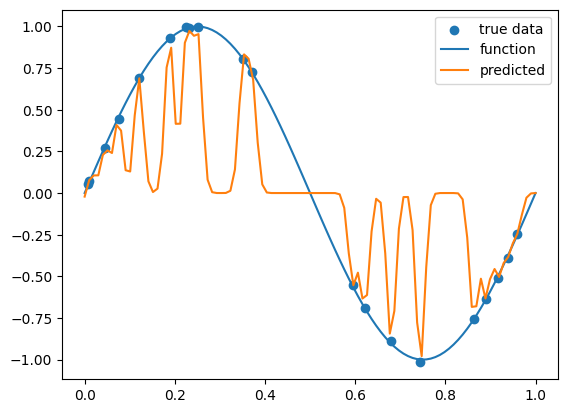

In [5]:
# make somme data
n = 20
sig = 0.01
x = np.random.rand(n)
# print(x)
y = np.sin(x* 2*np.pi) + sig*np.random.randn(n)
print(x.shape)
print(y.shape)

xth = np.linspace(0,1, 100)
yth = np.sin(xth * 2*np.pi)

# create a gaussian process object
gauss = GP.GPR(n, 1, "RBF", sig)
# fit the gaussian process to the given data, for some sigma_f and l
gauss.fit(np.array([x]), y, theta=np.array([10, 1e-4])) # changing the hyperparameters gives you different fits
# new_x = np.random.rand(5)
new_y = gauss.predict_aft_K(xth)

fig = plt.figure()
plt.scatter(x, y, label="true data")
plt.plot(xth, yth, label="function")
plt.plot(xth, new_y, label="predicted")

plt.legend()

To find the best hyperparameters, we want to optimize some function. In our case that function is given by the **likelihood**, which is the probability that the given outputs, $y$ show up if those outputs obey a function $f$ satisfying 
$$
\text{Cov}(f(x_i), f(x_j)) = K_{i,j} = k(x_i, x_j)
$$

Typically, people optimize the log of that probability because it is easier to deal with. In our case this will be 
$$
\log(p(y | X,\theta)) = -\frac{1}{2}(y^T \hat{K}^{-1} y+ \text{tr}(\log(\hat{K})) + n\log(2\pi))
$$

In [12]:
# try optimizing
gauss.grad_dec_theta(np.array([1, 1]), alpha=1e-5)
new_y = gauss.predict_aft_K(xth)

fig = plt.figure()
plt.scatter(x, y, label="true data")
plt.plot(xth, yth, label="function")
plt.plot(xth, new_y, label="predicted")

plt.legend()

Running gradient descent with theta0 =  [1 1]
Using a stopping condition of ||nabla f||^2 < 1e-05
Using a step size of 1e-05
Iteration 0
theta =  [1 1]
log liklihood =  -1702.8070709432475
Iteration 1
theta =  [54.49636055  0.95536125]
log liklihood =  3.4745860464854132
Iteration 2
theta =  [137.23372724   0.95422777]
log liklihood =  20.620147096828582
Iteration 3
theta =  [154.85374941   0.95399409]
log liklihood =  21.054467912841474
Iteration 4
theta =  [171.97460445   0.9538271 ]
log liklihood =  21.233740490339017
Iteration 5
theta =  [189.53333069   0.95369538]
log liklihood =  21.262509907928276
Iteration 6
theta =  [208.15510085   0.9536192 ]
log liklihood =  21.184055861849536
Iteration 7
theta =  [228.36790686   0.95352793]
log liklihood =  21.019631081577103
Iteration 8
theta =  [250.68755469   0.95333735]
log liklihood =  20.77980721978043
Iteration 9
theta =  [275.66459091   0.95331334]
log liklihood =  20.469976203547333
Iteration 10
theta =  [303.9023571    0.95326835]

LinAlgError: Singular matrix

In [7]:
# create a gaussian process object
gauss = GP.GPR(n, 1, "RBF", sig)
# fit the gaussian process to the given data, for some sigma_f and l
gauss.fit(np.array([x]), y, theta=np.array([sig*10, 1e-2])) # changing the hyperparameters gives you different fits
thetas = gauss.grad_dec_theta(theta0=np.array([10,1e-4]), alpha=1e-5, return_theta=True, max_iter=100)

Running gradient descent with theta0 =  [1.e+01 1.e-04]
Using a stopping condition of ||nabla f||^2 < 1e-05
Using a step size of 1e-05
Iteration 0
theta =  [1.e+01 1.e-04]
log liklihood =  -60.78489323687563
Iteration 1
theta =  [9.99990479 0.24490365]
log liklihood =  33.291879739238695
Iteration 2
theta =  [8.63621657 0.24511814]
log liklihood =  34.0608400678436
Iteration 3
theta =  [7.39912317 0.24528222]
log liklihood =  34.78617780167459
Iteration 4
theta =  [6.28833906 0.24537921]
log liklihood =  35.428931274909566
Iteration 5
theta =  [5.30672146 0.24538587]
log liklihood =  35.93022818342338
Iteration 6
theta =  [4.45930511 0.24527061]
log liklihood =  36.21130511144623
Iteration 7
theta =  [3.75206769 0.24499294]
log liklihood =  36.189103482316995
Iteration 8
theta =  [3.18971125 0.24450765]
log liklihood =  35.82269308209675
Iteration 9
theta =  [2.77086347 0.24377737]
log liklihood =  35.18182908943884
Iteration 10
theta =  [2.48126704 0.24279228]
log liklihood =  34.4580

## Animating Model Predictions Over Gradient Descent Iterations

You can create an animated plot showing how predictions evolve across gradient descent iterations using `matplotlib.animation.FuncAnimation`.

In [8]:
%matplotlib notebook

In [9]:
import matplotlib.pyplot as plt
import matplotlib.animation


# t = np.linspace(0,2*np.pi)
# x = np.sin(t)
y_preds = []
for theta_vec in thetas:
    print(theta_vec)
    g = GP.GPR(n, 1, "RBF", sig)
    g.fit(np.array([x]), y, theta=theta_vec)
    y_preds.append(g.predict_aft_K(xth))

fig, ax = plt.subplots()
ax.axis([0,1,-1.1,1.1])
plt.plot(xth, yth, alpha=0.3)
l, = ax.plot([],[])


def animate(i):
    l.set_data(xth, y_preds[i])
    # l.set_data(xth, yth)

ani = matplotlib.animation.FuncAnimation(fig, animate, frames=len(thetas))

from IPython.display import HTML
HTML(ani.to_jshtml())

[1.e+01 1.e-04]
[9.99990479 0.24490365]
[8.63621657 0.24511814]
[7.39912317 0.24528222]
[6.28833906 0.24537921]
[5.30672146 0.24538587]
[4.45930511 0.24527061]
[3.75206769 0.24499294]
[3.18971125 0.24450765]
[2.77086347 0.24377737]
[2.48126704 0.24279228]
[2.29192967 0.24158181]
[2.16808617 0.24020161]
[2.08106755 0.23870652]
[2.01267622 0.23713472]
[1.95307013 0.23550748]
[1.89735602 0.23383479]
[1.84318647 0.2321202 ]
[1.78943978 0.23036379]
[1.73556606 0.22856369]
[1.68127728 0.2267168 ]
[1.62640255 0.22481908]
[1.57082067 0.22286564]
[1.51442814 0.22085065]
[1.45712353 0.21876724]
[1.39879921 0.21660724]
[1.33933641 0.21436084]
[1.27860169 0.21201623]
[1.21644416 0.20955892]
[1.95307013 0.23550748]
[1.89735602 0.23383479]
[1.84318647 0.2321202 ]
[1.78943978 0.23036379]
[1.73556606 0.22856369]
[1.68127728 0.2267168 ]
[1.62640255 0.22481908]
[1.57082067 0.22286564]
[1.51442814 0.22085065]
[1.45712353 0.21876724]
[1.39879921 0.21660724]
[1.33933641 0.21436084]
[1.27860169 0.21201623]


<IPython.core.display.Javascript object>